In [1]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, roc_auc_score)
from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid")
print("Libraries loaded ✓")

Libraries loaded ✓


In [2]:
# Cell 2 — load data and split
df = pd.read_csv('../data/processed_data.csv')

X = df.drop('isFraud', axis=1)
y = df['isFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set: {X_train.shape[0]:,} rows")
print(f"Test set: {X_test.shape[0]:,} rows")
print(f"Fraud in training set: {y_train.sum():,}")

Training set: 2,216,327 rows
Test set: 554,082 rows
Fraud in training set: 6,570


In [3]:
# apply SMOTE to training set only
print("Applying SMOTE")
print(f"Before SMOTE — Fraud: {y_train.sum():,} | Legitimate: {(y_train==0).sum():,}")

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"After SMOTE  — Fraud: {y_train_smote.sum():,} | Legitimate: {(y_train_smote==0).sum():,}")
print(f"\nTraining set size after SMOTE: {X_train_smote.shape[0]:,}")

Applying SMOTE
Before SMOTE — Fraud: 6,570 | Legitimate: 2,209,757
After SMOTE  — Fraud: 2,209,757 | Legitimate: 2,209,757

Training set size after SMOTE: 4,419,514


In [4]:
# train Random Forest



rf_model = RandomForestClassifier(
    n_estimators=100,      # 100 decision trees
    max_depth=10,          # each tree can ask max 10 questions
    random_state=42,
    n_jobs=-1              # use all CPU cores to speed up training
)

rf_model.fit(X_train_smote, y_train_smote)
print("Random Forest trained")

Random Forest trained


In [5]:
# evaluate Random Forest
y_pred_rf = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf)
recall = recall_score(y_test, y_pred_rf)
f1 = f1_score(y_test, y_pred_rf)
roc_auc = roc_auc_score(y_test, y_pred_rf)

print("=" * 45)
print("RANDOM FOREST + SMOTE RESULTS")
print("=" * 45)
print(f"Accuracy:  {accuracy*100:.2f}%")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}  ← most important")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")
print("=" * 45)
print("\nComparison with baseline:")
print(f"Recall:  0.4461 → {recall:.4f}")
print(f"ROC-AUC: 0.7229 → {roc_auc:.4f}")

RANDOM FOREST + SMOTE RESULTS
Accuracy:  99.99%
Precision: 0.9540
Recall:    0.9976  ← most important
F1 Score:  0.9753
ROC-AUC:   0.9987

Comparison with baseline:
Recall:  0.4461 → 0.9976
ROC-AUC: 0.7229 → 0.9987


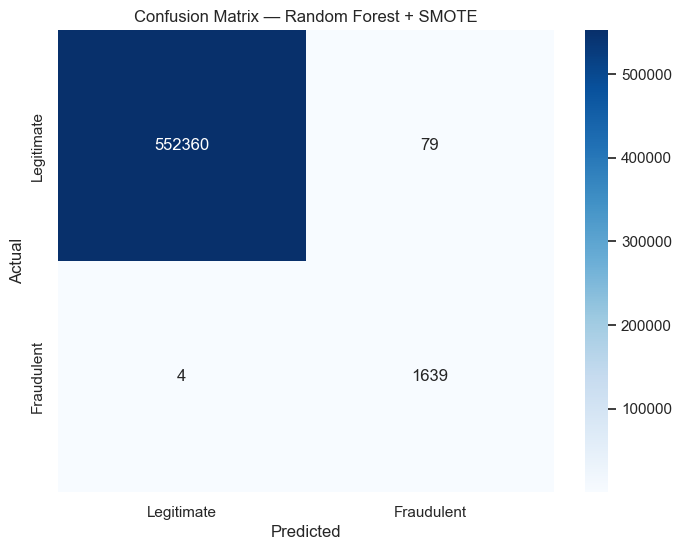


Actual fraud cases:     1,643
Fraud caught (TP):      1,639
Fraud missed (FN):      4
Legitimate blocked (FP): 79


In [6]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraudulent'],
            yticklabels=['Legitimate', 'Fraudulent'])
plt.title('Confusion Matrix — Random Forest + SMOTE')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('../notebooks/confusion_matrix_rf.png', dpi=150, bbox_inches='tight') #saves fiure in directory
plt.show()

print(f"\nActual fraud cases:     {y_test.sum():,}")
print(f"Fraud caught (TP):      {cm[1][1]:,}")
print(f"Fraud missed (FN):      {cm[1][0]:,}")
print(f"Legitimate blocked (FP): {cm[0][1]:,}")

/var/folders/bg/__y_51jj02x82ln1bpd88_yc0000gn/T/ipykernel_17663/3474354885.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


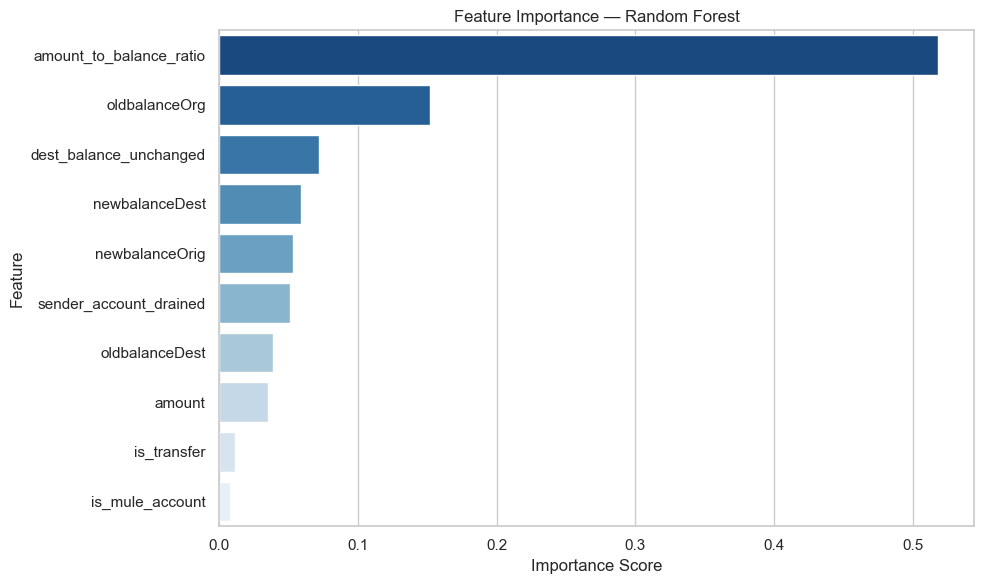


Feature Importance Ranking:
                feature  importance
amount_to_balance_ratio    0.517887
          oldbalanceOrg    0.152366
 dest_balance_unchanged    0.071866
         newbalanceDest    0.059329
         newbalanceOrig    0.053141
 sender_account_drained    0.050880
         oldbalanceDest    0.038846
                 amount    0.035715
            is_transfer    0.011662
        is_mule_account    0.008307


In [7]:
# feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance,
    x='importance',
    y='feature',
    palette='Blues_r'
)
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('../notebooks/feature_importance_rf.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFeature Importance Ranking:")
print(feature_importance.to_string(index=False))

In [8]:
# save model
import joblib

joblib.dump(rf_model, '../models/random_forest.joblib')
print("Random Forest model saved ✓")

Random Forest model saved ✓


In [9]:
# phase 4 summary
print("=" * 45)
print("PHASE 4 COMPLETE")
print("=" * 45)
print("\nBaseline vs Random Forest + SMOTE:")
print(f"{'Metric':<12} {'Baseline':>10} {'RF+SMOTE':>10} {'Change':>10}")
print("-" * 45)
print(f"{'Recall':<12} {'0.4461':>10} {'0.9976':>10} {'↑ +0.5515':>10}")
print(f"{'Precision':<12} {'0.8435':>10} {'0.9540':>10} {'↑ +0.1105':>10}")
print(f"{'F1':<12} {'0.5836':>10} {'0.9753':>10} {'↑ +0.3917':>10}")
print(f"{'ROC-AUC':<12} {'0.7229':>10} {'0.9987':>10} {'↑ +0.2758':>10}")
print("=" * 45)
print("\nTop fraud signals identified:")
print("  1. amount_to_balance_ratio  (51.7%)")
print("  2. oldbalanceOrg            (15.2%)")
print("  3. dest_balance_unchanged   (7.2%)")
print("=" * 45)

PHASE 4 COMPLETE

Baseline vs Random Forest + SMOTE:
Metric         Baseline   RF+SMOTE     Change
---------------------------------------------
Recall           0.4461     0.9976  ↑ +0.5515
Precision        0.8435     0.9540  ↑ +0.1105
F1               0.5836     0.9753  ↑ +0.3917
ROC-AUC          0.7229     0.9987  ↑ +0.2758

Top fraud signals identified:
  1. amount_to_balance_ratio  (51.7%)
  2. oldbalanceOrg            (15.2%)
  3. dest_balance_unchanged   (7.2%)
